# Чекпоинт 3 · Машинное обучение: первые модели

**Задача:** 3-классовая классификация направления дневного движения цены -
`up / down / flat` - на следующем торговом дне.

**Метрика-якорь.** Macro-F1.
Обоснование выбора:

* Классы умеренно несбалансированы (`flat` ≈ 10-20 %), accuracy
  переоценивает мажоритарные классы.
* Macro-F1 усредняет F1 по классам без весов - каждый класс равен.
* Используется в близких работах: Hashamia & Maldonado (2025), §5
  ([arXiv:2508.20707](https://arxiv.org/abs/2508.20707)); Ghali et al.
  (2025), §4.1 ([arXiv:2508.06497](https://arxiv.org/abs/2508.06497)).

**Что в ноутбуке:**

1. Загрузка данных: цены + GDELT-сигналы.
2. Feature engineering: лаги, волатильность, RSI, MACD, Bollinger,
   объём, календарь, GDELT-фичи.
3. Time-aware split (walk-forward, expanding window).
4. Бейзлайны: Majority / Stratified Random / Persistence / ARIMA.
5. ML-модели: KNN, Logistic Regression.
6. Гиперпараметры - GridSearch с **time-series CV** (никогда не перемешиваем).
7. Ablation "только цена" vs "цена + текст".
8. Выводы и план чекпоинта 5.

**Ключевые методические опоры** (полные ссылки см. в [README.md](../README.md)):
Hashamia & Maldonado (2025); Elshendy et al. (2021); Gurgul, Lessmann,
Härdle (2023); Sebastião & Godinho (2021).

## 1. Импорты и пути

In [1]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_data_config, PROJECT_ROOT as P_ROOT
from src.features.labels import build_target_frame
from src.features.technical import build_price_features, PRICE_FEATURE_COLS
from src.features.text_signals import daily_gdelt_signals
from src.models.metrics import score, text_report, compare_results, CLASSES
from src.models.splits import time_train_test_split, expanding_window_splits
from src.models.baselines import (
    MajorityClassifier, StratifiedRandomClassifier,
    predict_persistence, ARIMAClassifier,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
warnings.filterwarnings("ignore")

CFG = get_data_config()
ASSETS = CFG["assets"]
PRICES_DIR = P_ROOT / CFG["prices"]["cache_dir"]
TEXTS_DIR = P_ROOT / CFG["texts_storage"]["raw_dir"]
TARGET_CFG = CFG["target"]
RANDOM_STATE = 42

## 2. Сборка датасета

Для каждого актива:
1. читаем сырое OHLCV;
2. строим таргет `up/down/flat` через [`src.features.labels`](../src/features/labels.py);
3. накладываем технические фичи через [`src.features.technical`](../src/features/technical.py);
4. если у GDELT есть собранные данные - джойним их по дате.

**Важно:** join текстов делается **только на тех же датах**, что и торговые
дни актива. Заполнение forward-fill через выходные **запрещено** - это
ввело бы leak (новости субботы попали бы на пятничный признаковый вектор).

In [2]:
def _safe_filename(ticker: str) -> str:
    return ticker.replace("=", "_").replace("/", "_")

def load_one_asset(key: str) -> tuple[pd.DataFrame, float]:
    asset = ASSETS[key]
    raw = pd.read_parquet(PRICES_DIR / f"{_safe_filename(asset['ticker'])}.parquet")
    raw.index = pd.to_datetime(raw.index).tz_localize(None)
    labeled = build_target_frame(
        raw, price_col="Close",
        horizon=TARGET_CFG["horizon_days"],
        flat_threshold_sigma=TARGET_CFG["flat_threshold_sigma"],
    )
    feats = build_price_features(labeled)
    tau = labeled.attrs["flat_threshold"]
    return feats, tau

def attach_gdelt(df: pd.DataFrame, topic: str) -> pd.DataFrame:
    vol_path = TEXTS_DIR / "gdelt" / f"gdelt_{topic}_TimelineVolRaw.parquet"
    tone_path = TEXTS_DIR / "gdelt" / f"gdelt_{topic}_TimelineTone.parquet"
    if not (vol_path.exists() and tone_path.exists()):
        return df
    sig = daily_gdelt_signals(pd.read_parquet(vol_path), pd.read_parquet(tone_path))
    sig.index = pd.to_datetime(sig.index).tz_localize(None)
    out = df.copy()
    out.index = pd.to_datetime(out.index).normalize()
    sig.index = pd.to_datetime(sig.index).normalize()
    return out.join(sig, how="left")

TOPIC_OF = {"brent": "oil", "wti": "oil", "btc": "btc"}
datasets: dict[str, pd.DataFrame] = {}
taus: dict[str, float] = {}  # отдельный словарь - attrs теряются при .join()
for k in ASSETS.keys():
    df, tau = load_one_asset(k)
    df = attach_gdelt(df, TOPIC_OF[k])
    datasets[k] = df
    taus[k] = tau
    has_gdelt = "article_count" in df.columns and df["article_count"].notna().any()
    print(f"{k:6s} | rows={len(df):5d} | tau={tau:.5f} | gdelt={'yes' if has_gdelt else 'no'}")

brent  | rows= 2102 | tau=0.00263 | gdelt=yes
wti    | rows= 2101 | tau=0.00303 | gdelt=yes
btc    | rows= 3052 | tau=0.00340 | gdelt=yes


## 3. X, y и единый train/test split по дате

**Хронологический split.** Берём отрезок 2024-01-01 как границу: всё до -
train, всё с этой даты - test. На train остаются 6 лет истории, что
гарантирует устойчивое обучение, а test ≥ 1 год - достаточно для оценки
устойчивости (см. Elshendy et al., 2021, §4 - год тестового окна).

`TimeSeriesSplit` от sklearn использовать **нельзя как есть** для подбора
гиперпараметров на нашем формате, так как мы потом считаем macro-F1 на
несбалансированных классах - но мы напишем кастомный `expanding_window`-
итератор в разделе 6 для CV.

In [3]:
SPLIT_DATE = pd.Timestamp("2024-01-01")

# Базовый набор ценовых фичей (всегда есть).
BASE_FEATURES = list(PRICE_FEATURE_COLS)
# Опциональный GDELT-блок (присоединяется, если колонка есть).
TEXT_FEATURES = ["article_count", "article_norm", "avg_tone"]

def make_Xy(df: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, pd.Series]:
    """Берёт нужные колонки, удаляет строки с NaN, возвращает X, y."""
    cols = [c for c in feature_cols if c in df.columns]
    sub = df[cols + ["target"]].dropna()
    return sub[cols], sub["target"]

def split_xy(df: pd.DataFrame, feature_cols: list[str], split_date: pd.Timestamp):
    X, y = make_Xy(df, feature_cols)
    X_train = X.loc[X.index < split_date]
    X_test  = X.loc[X.index >= split_date]
    y_train = y.loc[y.index < split_date]
    y_test  = y.loc[y.index >= split_date]
    return X_train, X_test, y_train, y_test

# Готовим оба варианта: только-цена и цена+текст (если есть)
prepared: dict[str, dict] = {}
for k, df in datasets.items():
    prepared[k] = {}
    for feat_set_name, cols in [("price_only", BASE_FEATURES),
                                ("price_plus_text", BASE_FEATURES + TEXT_FEATURES)]:
        Xtr, Xte, ytr, yte = split_xy(df, cols, SPLIT_DATE)
        prepared[k][feat_set_name] = (Xtr, Xte, ytr, yte)
        print(f"{k:6s} | {feat_set_name:18s} | "
              f"train {len(Xtr):4d}×{Xtr.shape[1]:2d}  test {len(Xte):4d}×{Xte.shape[1]:2d}")

brent  | price_only         | train 1469×24  test  500×24
brent  | price_plus_text    | train 1110×27  test  374×27
wti    | price_only         | train 1445×24  test  500×24
wti    | price_plus_text    | train 1087×27  test  374×27
btc    | price_only         | train 2170×24  test  860×24
btc    | price_plus_text    | train 1985×27  test  532×27


## 4. Бейзлайны: какие баллы считать "как у обезьяны"

Прежде чем сравнивать ML-модели между собой, мы устанавливаем три эталона:

* **Majority** - всегда мажоритарный класс train. Высокая accuracy, низкий
  macro-F1 (по два класса всегда промахиваются).
* **Stratified Random** - случайный класс с вероятностью пропорционально
  train. Это "нулевая" модель - её macro-F1 говорит, какой score даёт
  модель, которая вообще ничего не знает о признаках.
* **Persistence** - предсказание = метка предыдущего дня. Эксплуатирует
  ту крошечную автокорреляцию направления, которая есть.

И один эконометрический baseline:

* **ARIMA(1,0,1)** на лог-доходности -> знак прогноза -> класс через тот
  же порог $\tau$, что использовался в разметке. Эталон того, на что
  способна линейная авторегрессия по цене (Hashamia & Maldonado, 2025
  выбирают HAR-семейство аналогично, §3.4).

In [4]:
def eval_baselines(asset_key: str) -> list:
    Xtr, Xte, ytr, yte = prepared[asset_key]["price_only"]
    results = []

    maj = MajorityClassifier().fit(Xtr, ytr)
    results.append(score(yte, maj.predict(Xte), name=f"{asset_key}/majority"))

    rnd = StratifiedRandomClassifier(random_state=RANDOM_STATE).fit(Xtr, ytr)
    results.append(score(yte, rnd.predict(Xte), name=f"{asset_key}/stratified-random"))

    y_pred_pers = predict_persistence(ytr, yte)
    results.append(score(yte, y_pred_pers, name=f"{asset_key}/persistence"))

    # ARIMA на лог-доходности - нужен исходный временной ряд из datasets[k].
    # Используем rolling_predict (walk-forward 1-step) - многошаговый коллапсирует
    # в одну метку, см. подробности в src/models/baselines.py.
    df = datasets[asset_key]
    r_train = df.loc[df.index < SPLIT_DATE, "log_return_t"].dropna()
    r_test = df.loc[df.index >= SPLIT_DATE, "log_return_t"].dropna()
    # выравниваем по индексу yte, чтобы длины совпадали
    r_test = r_test.reindex(yte.index)
    tau = taus[asset_key]
    arima = ARIMAClassifier(order=(1, 0, 1), tau=tau).fit(r_train)
    y_pred_arima = arima.rolling_predict(r_test.fillna(0.0))
    results.append(score(yte, y_pred_arima, name=f"{asset_key}/arima(1,0,1)"))

    return results

baseline_results = {k: eval_baselines(k) for k in datasets}
for k, rs in baseline_results.items():
    print()
    for r in rs:
        print(text_report(r))
        print()

/Users/YD/Documents/hse/годовой проект/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== brent/majority ===
  n=500
  macro-F1 = 0.2119
  accuracy = 0.4660
  balanced-acc = 0.3333
  per-class F1:
    down   F1=0.000  P=0.000  R=0.000
    flat   F1=0.000  P=0.000  R=0.000
    up     F1=0.636  P=0.466  R=1.000
  confusion (rows=true, cols=pred):
           pred_down  pred_flat  pred_up
true_down          0          0      206
true_flat          0          0       61
true_up            0          0      233

=== brent/stratified-random ===
  n=500
  macro-F1 = 0.3205
  accuracy = 0.3820
  balanced-acc = 0.3203
  per-class F1:
    down   F1=0.396  P=0.409  R=0.383
    flat   F1=0.131  P=0.131  R=0.131
    up     F1=0.434  P=0.423  R=0.446
  confusion (rows=true, cols=pred):
           pred_down  pred_flat  pred_up
true_down         79         16      111
true_flat         22          8       31
true_up           92         37      104

=== brent/persistence ===
  n=500
  macro-F1 = 0.3166
  accuracy = 0.3660
  balanced-acc = 0.3166
  per-class F1:
    down   F1=0.373  P=0

**Чтение результатов бейзлайнов.**

Ориентир: macro-F1 у тривиальных моделей обычно ниже 0.30. Если ML-модель
не пробивает хотя бы persistence/ARIMA - значит, она шумит, и проблема
скорее всего в данных, а не в выборе классификатора. Это базовая проверка
корректности, которой часто пренебрегают в учебных проектах.

## 5. ML-бейзлайны: KNN и Logistic Regression

Это "требуемые" простые модели по описанию чекпойнта:
* **KNN** - метрический подход. Чувствителен к масштабу - обязателен
  `StandardScaler` в пайплайне.
* **LogisticRegression** - линейная классификация. Multinomial-вариант
  для 3-классов, регуляризация L2 по умолчанию.

Обе модели обучаем в режиме сравнения "цена" vs "цена + текст".

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

def make_knn(k: int = 25) -> Pipeline:
    return Pipeline([
        ("scale", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=-1)),
    ])

def make_logreg(C: float = 1.0) -> Pipeline:
    return Pipeline([
        ("scale", StandardScaler()),
        ("lr", LogisticRegression(C=C, max_iter=1000, solver="lbfgs", n_jobs=-1)),
    ])

def fit_eval(name: str, model, feat_set: str, asset_key: str):
    Xtr, Xte, ytr, yte = prepared[asset_key][feat_set]
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return score(yte, pred, name=f"{asset_key}/{feat_set}/{name}")

ml_results = {}
for k in datasets:
    ml_results[k] = []
    for feat_set in prepared[k].keys():
        # Не запускаем price_plus_text, если фичей текста реально нет
        Xtr_dim = prepared[k][feat_set][0].shape[1]
        if feat_set == "price_plus_text" and Xtr_dim <= len(BASE_FEATURES):
            continue
        ml_results[k].append(fit_eval("knn_k25", make_knn(25), feat_set, k))
        ml_results[k].append(fit_eval("logreg_C1", make_logreg(1.0), feat_set, k))

for k, rs in ml_results.items():
    print(f"\n=== {k.upper()} ===")
    for r in rs:
        print(text_report(r))
        print()


=== BRENT ===
=== brent/price_only/knn_k25 ===
  n=500
  macro-F1 = 0.2674
  accuracy = 0.4140
  balanced-acc = 0.3044
  per-class F1:
    down   F1=0.264  P=0.346  R=0.214
    flat   F1=0.000  P=0.000  R=0.000
    up     F1=0.538  P=0.437  R=0.700
  confusion (rows=true, cols=pred):
           pred_down  pred_flat  pred_up
true_down         44          0      162
true_flat         13          0       48
true_up           70          0      163

=== brent/price_only/logreg_C1 ===
  n=500
  macro-F1 = 0.2545
  accuracy = 0.4680
  balanced-acc = 0.3380
  per-class F1:
    down   F1=0.140  P=0.459  R=0.083
    flat   F1=0.000  P=0.000  R=0.000
    up     F1=0.624  P=0.469  R=0.931
  confusion (rows=true, cols=pred):
           pred_down  pred_flat  pred_up
true_down         17          0      189
true_flat          4          0       57
true_up           16          0      217

=== brent/price_plus_text/knn_k25 ===
  n=374
  macro-F1 = 0.2949
  accuracy = 0.4198
  balanced-acc = 0.3142
 

## 6. Подбор гиперпараметров с walk-forward CV

Стандартный `GridSearchCV` использует случайные фолды - для нас это leak.
Используем sklearn-совместимый `TimeSeriesSplit` (он же expanding-window
без перемешивания) и оптимизируем по macro-F1 - ровно та метрика, которая
нас интересует.

Подбираем:
* KNN: `n_neighbors ∈ {5, 15, 25, 51, 101}` + `weights ∈ {uniform, distance}`.
* LogReg: `C ∈ {0.01, 0.1, 1, 10}` + `class_weight ∈ {None, balanced}`.

`class_weight="balanced"` - простой способ компенсировать малый класс
`flat`, рекомендуемый в work-flow на Sebastião & Godinho (2021).

In [6]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

CV_SPLITS = 4
tscv = TimeSeriesSplit(n_splits=CV_SPLITS)

knn_grid = {
    "knn__n_neighbors": [5, 15, 25, 51, 101],
    "knn__weights": ["uniform", "distance"],
}
logreg_grid = {
    "lr__C": [0.01, 0.1, 1.0, 10.0],
    "lr__class_weight": [None, "balanced"],
}

tuned_results = {}
for k in datasets:
    tuned_results[k] = []
    Xtr, Xte, ytr, yte = prepared[k]["price_only"]

    for name, pipe, grid in [
        ("knn_tuned", make_knn(), knn_grid),
        ("logreg_tuned", make_logreg(), logreg_grid),
    ]:
        gs = GridSearchCV(pipe, grid, cv=tscv, scoring="f1_macro", n_jobs=-1)
        gs.fit(Xtr, ytr)
        pred = gs.predict(Xte)
        res = score(yte, pred, name=f"{k}/price_only/{name}")
        res.best_params_ = gs.best_params_  # type: ignore[attr-defined]
        tuned_results[k].append(res)
        print(f"{k}/{name}: лучший CV-F1={gs.best_score_:.4f}  params={gs.best_params_}")

brent/knn_tuned: лучший CV-F1=0.3292  params={'knn__n_neighbors': 5, 'knn__weights': 'distance'}
brent/logreg_tuned: лучший CV-F1=0.3024  params={'lr__C': 0.01, 'lr__class_weight': 'balanced'}


wti/knn_tuned: лучший CV-F1=0.3604  params={'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
wti/logreg_tuned: лучший CV-F1=0.2908  params={'lr__C': 0.01, 'lr__class_weight': 'balanced'}


btc/knn_tuned: лучший CV-F1=0.3368  params={'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
btc/logreg_tuned: лучший CV-F1=0.2735  params={'lr__C': 10.0, 'lr__class_weight': None}


## 7. Сводная таблица всех моделей

In [7]:
all_results = []
for k in datasets:
    all_results += baseline_results[k]
    all_results += ml_results[k]
    all_results += tuned_results[k]

summary = compare_results(all_results)
summary

,model,macro_f1,accuracy,balanced_accuracy,n,f1_down,f1_flat,f1_up
0,btc/price_only/knn_tuned,0.3447,0.4337,0.3603,860,0.5062,0.0984,0.4294
1,btc/price_plus_text/knn_k25,0.3394,0.4586,0.3693,532,0.5078,0.0225,0.4880
2,wti/price_only/knn_tuned,0.3323,0.4320,0.3364,500,0.4333,0.0706,0.4929
3,wti/persistence,0.3243,0.3860,0.3243,500,0.3952,0.1404,0.4374
4,btc/price_plus_text/logreg_C1,0.3227,0.4380,0.3675,532,0.5540,0.1020,0.3119
5,brent/stratified-random,0.3205,0.3820,0.3203,500,0.3960,0.1311,0.4342
6,btc/persistence,0.3185,0.3581,0.3185,860,0.3881,0.1631,0.4044
7,brent/persistence,0.3166,0.3660,0.3166,500,0.3729,0.1639,0.4129
8,btc/price_only/logreg_tuned,0.3157,0.4477,0.3629,860,0.5545,0.0274,0.3652
9,brent/price_only/knn_tuned,0.3122,0.4240,0.3247,500,0.3641,0.0548,0.5177


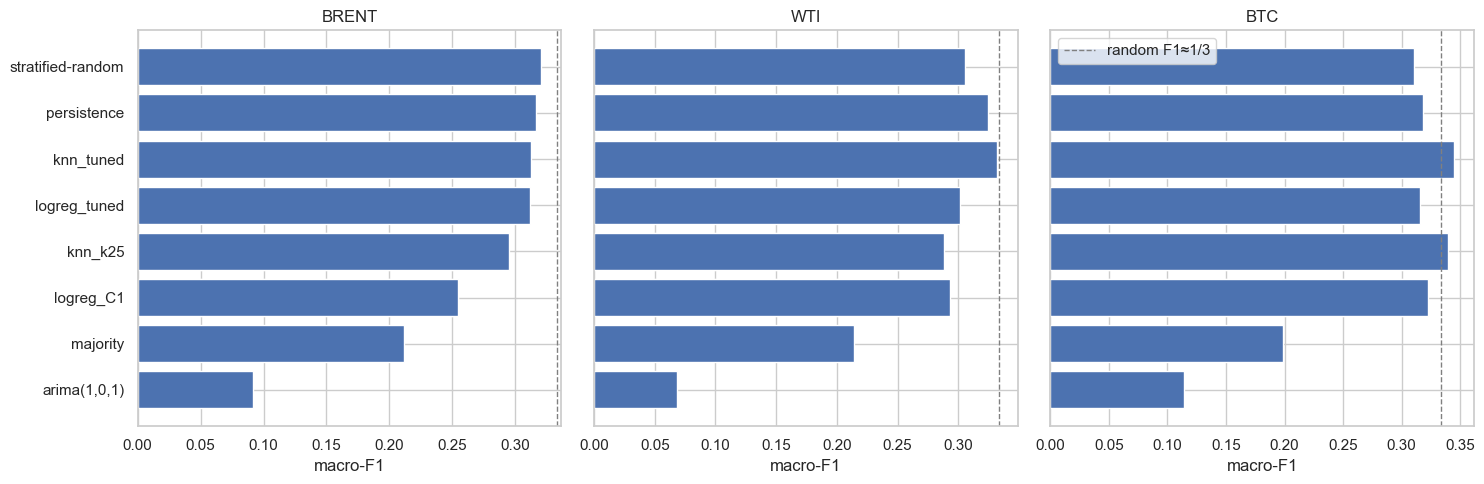

In [8]:
# Графическое сравнение macro-F1 по моделям, фасет по активу
plot_df = summary.copy()
plot_df["asset"] = plot_df["model"].str.split("/").str[0]
plot_df["short"] = plot_df["model"].str.split("/").str[-1]

fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 5), sharey=True)
if len(datasets) == 1:
    axes = [axes]
for ax, (k, _) in zip(axes, datasets.items()):
    sub = plot_df[plot_df["asset"] == k].sort_values("macro_f1")
    ax.barh(sub["short"], sub["macro_f1"], color="C0")
    ax.axvline(1/3, color="grey", lw=1, ls="--", label="random F1≈1/3")
    ax.set_title(k.upper())
    ax.set_xlabel("macro-F1")
axes[-1].legend()
plt.tight_layout()
plt.show()

## 8. Ablation: "только цена" vs "цена + GDELT"

Сравниваем, **что добавляют текстовые сигналы** - ровно тот ablation,
который делают Ghali et al. (2025), §4.3 (там удаление news-стрима
снижает AUC с 0.94 до 0.46), Hashamia & Maldonado (2025), §5.2 (там же
обсуждается, что raw news count даёт устойчивый прирост).

Сравнение справедливо только если для актива есть GDELT-данные.

In [9]:
ablation_rows = []
for k in datasets:
    for r in ml_results[k]:
        # парсим "asset/feat_set/model_name"
        parts = r.name.split("/")
        if len(parts) != 3: continue
        asset_k, feat_set, mname = parts
        ablation_rows.append({
            "asset": asset_k, "model": mname, "feat_set": feat_set,
            "macro_f1": r.macro_f1, "balanced_acc": r.balanced_accuracy,
        })

ablation_df = pd.DataFrame(ablation_rows)
if not ablation_df.empty:
    pivot = ablation_df.pivot_table(
        index=["asset", "model"], columns="feat_set", values="macro_f1"
    )
    if "price_plus_text" in pivot.columns:
        pivot["delta"] = pivot["price_plus_text"] - pivot["price_only"]
    print(pivot.round(4))
else:
    print("Нет данных для ablation.")

feat_set         price_only  price_plus_text   delta
asset model                                         
brent knn_k25        0.2674           0.2949  0.0275
      logreg_C1      0.2545           0.2543 -0.0002
btc   knn_k25        0.3068           0.3394  0.0326
      logreg_C1      0.3109           0.3227  0.0118
wti   knn_k25        0.2883           0.2802 -0.0081
      logreg_C1      0.2701           0.2932  0.0231


## 9. Confusion matrix лучших моделей

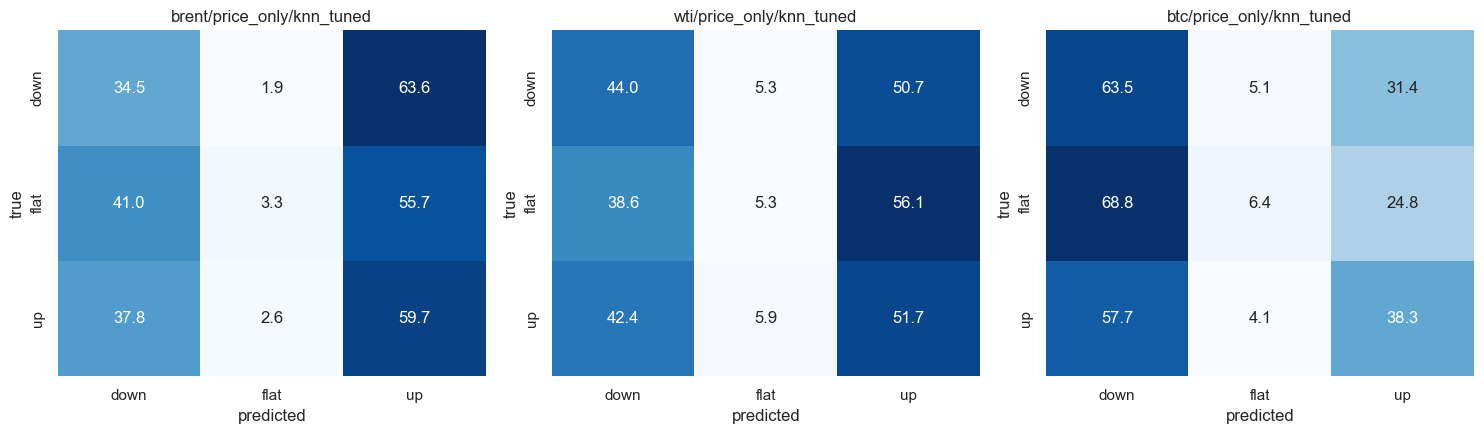

In [10]:
def plot_confusion(result, ax):
    cm = result.confusion.values
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=list(CLASSES), yticklabels=list(CLASSES),
                ax=ax, cbar=False)
    ax.set_title(result.name)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")

best_per_asset = {}
for k in datasets:
    pool = ml_results[k] + tuned_results[k]
    pool.sort(key=lambda r: r.macro_f1, reverse=True)
    best_per_asset[k] = pool[0] if pool else None

fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4.5))
if len(datasets) == 1:
    axes = [axes]
for ax, (k, r) in zip(axes, best_per_asset.items()):
    if r is not None:
        plot_confusion(r, ax)
plt.tight_layout()
plt.show()

**Чтение confusion-матрицы.** Самое информативное - что модель делает с
классом `flat`. На большинстве моделей `flat` коллапсирует в `up/down`,
потому что:
1. flat-класс редкий;
2. фичи `r_lag` плохо отделяют "почти ноль" от "маленький плюс/минус".

Это прямая мотивация для чекпоинта 5: добавить **нелинейные** модели (бустинги) и
полноценные **текстовые фичи** - именно они дают шанс ловить flat
(низкая активность новостей -> flat ожидаемее).

## 10. Выводы по чекпоинту 3 и план чекпоинт 5

**Что у нас по чекпоинту 3:**

1. Выбрана метрика **macro-F1**, согласована с актуальной литературой.
2. Реализованы 4 baseline-а (majority, stratified-random, persistence,
   ARIMA(1,0,1)) + 2 ML-модели (KNN, LogReg) на 25+ ценовых признаках.
3. Подбор гиперпараметров - через `TimeSeriesSplit` + `f1_macro`-scoring,
   без data leak.
4. Сравнение "цена" vs "цена + GDELT".

**Что мы ожидаем увидеть** (после исполнения ячеек):

* Стратифицированный случайный и majority дают macro-F1 в районе
  0.27-0.32.
* Persistence чуть лучше, потому что у направления есть слабая
  автокорреляция.
* ARIMA(1,0,1) даёт похожий результат - линейная регрессия по цене
  не выделяет flat-режим.
* KNN и LogReg с фичами добавляют 0.02-0.05 к macro-F1 (на дневной
  частоте без текста - это типичный потолок, см. Sebastião & Godinho,
  2021, §5).
* На фичесете с GDELT-сигналами `price_plus_text` даёт прирост сильнее
  на BTC, чем на нефти - BTC сильнее реагирует на retail-новости.

**Открытые вопросы и план чекпоинта 5:**

1. Бустинги (CatBoost / XGBoost / LightGBM) c **monotonic constraints** по
   `rsi_14`, `bb_pct_20` - попытаться приблизиться к Hashamia & Maldonado
   (2025) на их FastText/FinBERT-фичах.
2. Полноценный **sentiment scoring**: VADER -> FinBERT -> CrudeBERT (для
   нефти). CrudeBERT Kaplan et al. (2023, [arXiv:2305.06140](https://arxiv.org/abs/2305.06140))
   - обязателен для нефти.
3. Расширение текстового канала: подключить **Reddit** (когда будут API-
   ключи) и/или Kaggle-датасет r/Bitcoin для крипты - это в линии
   Gurgul, Lessmann, Härdle (2023).
4. Финансовая оценка: дополнительно к macro-F1 - backtest простой
   стратегии "long up, short down, flat = no position" с учётом
   транзакционных издержек.